In [7]:
import pandas as pd 
import numpy as np
netflix=pd.read_csv('netflix_customer_churn.csv')
netflix.head()

,customer_id,age,gender,subscription_type,watch_hours,last_login_days,region,device,monthly_fee,churned,payment_method,number_of_profiles,avg_watch_time_per_day,favorite_genre
0,a9b75100-82a8-427a-a208-72f24052884a,51,Other,Basic,14.73,29,Africa,TV,8.99,1,Gift Card,1,0.49,Action
1,49a5dfd9-7e69-4022-a6ad-0a1b9767fb5b,47,Other,Standard,0.70,19,Europe,Mobile,13.99,1,Gift Card,5,0.03,Sci-Fi
2,4d71f6ce-fca9-4ff7-8afa-197ac24de14b,27,Female,Standard,16.32,10,Asia,TV,13.99,0,Crypto,2,1.48,Drama
3,d3c72c38-631b-4f9e-8a0e-de103cad1a7d,53,Other,Premium,4.51,12,Oceania,TV,17.99,1,Crypto,2,0.35,Horror
4,4e265c34-103a-4dbb-9553-76c9aa47e946,56,Other,Standard,1.89,13,Africa,Mobile,13.99,1,Crypto,2,0.13,Action


In [9]:


X = netflix.drop(['customer_id', 'churned'], axis=1)
y = netflix['churned']

# Convert categorical columns into numerical columns
X = pd.get_dummies(X, drop_first=True)

print("Features:", X.shape)
print("Target:", y.shape)


Features: (5000, 29)
Target: (5000,)


In [10]:
from sklearn.model_selection import train_test_split

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [12]:
from sklearn.preprocessing import StandardScaler

In [13]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [14]:
from sklearn.linear_model import LogisticRegression

# Create the model
model = LogisticRegression(max_iter=1000)

# Train the model
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

print("Predictions:", y_pred)

Predictions: [0 1 1 1 1 1 1 1 0 1 0 0 0 0 0 0 1 0 1 0 1 1 0 0 0 1 0 0 0 1 1 0 0 1 1 0 0
 1 1 0 0 0 1 0 1 0 0 1 0 1 1 0 1 1 1 1 1 0 1 1 0 1 1 1 0 1 0 0 1 1 1 0 1 1
 0 0 1 1 1 1 0 0 0 1 0 0 0 0 0 0 0 1 1 1 0 0 1 1 1 0 1 0 0 1 0 1 1 1 0 1 1
 0 0 0 0 1 0 0 1 0 1 1 0 1 1 1 1 0 0 1 0 1 0 0 1 1 1 0 0 0 0 1 0 0 1 1 0 1
 0 1 0 0 0 1 1 0 0 0 0 0 1 1 0 0 0 0 0 0 1 0 0 0 1 0 1 1 0 1 1 1 1 1 1 0 0
 0 1 1 1 0 0 0 1 0 1 0 0 0 1 0 1 1 1 1 1 1 0 0 0 1 0 1 1 1 0 0 0 1 1 1 0 1
 0 0 0 0 0 1 1 0 1 1 1 1 1 1 0 1 0 1 1 1 1 1 0 1 0 0 1 1 1 0 0 0 1 0 0 1 0
 0 1 0 1 1 1 1 0 0 1 0 0 0 1 0 0 1 0 1 0 1 0 0 0 0 1 1 1 0 0 1 0 1 1 1 1 1
 0 0 1 0 1 0 0 1 1 1 1 1 0 0 0 1 1 0 0 1 1 1 1 0 0 1 0 1 1 1 1 0 0 0 1 0 0
 1 1 0 0 1 0 1 0 0 1 0 0 1 1 0 1 1 0 1 1 0 1 1 0 1 0 1 1 0 1 0 0 1 1 0 0 0
 0 1 0 1 0 0 0 1 1 0 0 1 0 1 1 0 0 1 0 1 1 1 1 0 1 0 1 0 0 1 0 1 1 0 1 1 1
 1 1 1 1 0 1 0 1 1 1 1 0 1 1 1 0 1 1 1 1 0 1 0 1 1 0 1 1 1 1 0 1 0 1 1 0 1
 0 1 1 0 1 0 1 1 0 1 1 1 1 0 0 0 0 0 1 1 1 0 1 0 0 0 1 1 0 1 1 1 1 1 1 0 1
 1 0 0 0 1 0

In [16]:
y_pred = model.predict(X_test)

In [17]:
from sklearn.metrics import accuracy_score

In [18]:
from sklearn.metrics import accuracy_score, classification_report

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("\nLogistic Regression Accuracy:")
print(accuracy)

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Logistic Regression Accuracy:
0.887

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.87      0.88       497
           1       0.88      0.90      0.89       503

    accuracy                           0.89      1000
   macro avg       0.89      0.89      0.89      1000
weighted avg       0.89      0.89      0.89      1000



In [19]:
from sklearn.metrics import confusion_matrix

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)


Confusion Matrix:
[[432  65]
 [ 48 455]]


In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

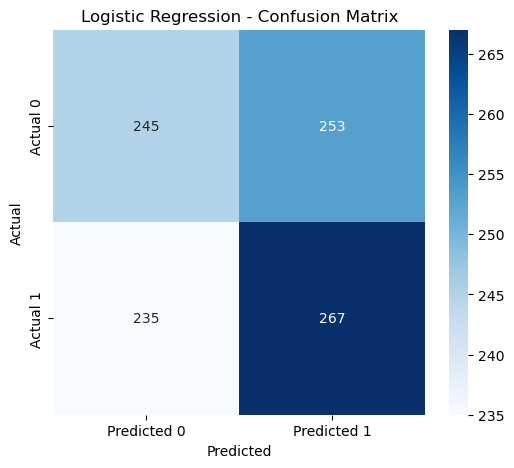

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot graph
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Predicted 0", "Predicted 1"],
    yticklabels=["Actual 0", "Actual 1"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression - Confusion Matrix")
plt.show()